FASE 1 

Grupo sanguíneo del padre: A
Grupo sanguíneo de la madre: AB

Posibles grupos sanguíneos del descendiente:
Grupo A: 50.00%
Grupo B: 12.50%
Grupo AB: 37.50%
Grupo O: 0.00%

Suposición: los genotipos posibles de cada grupo se consideran igual de probables.


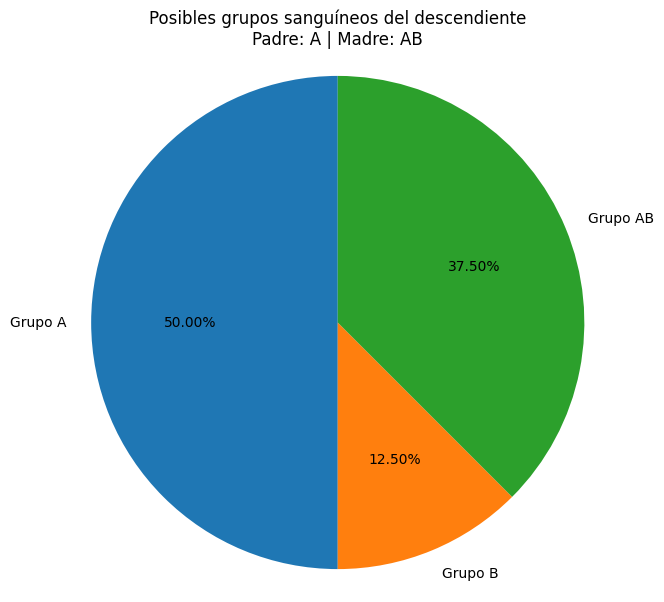

In [1]:
import matplotlib.pyplot as plt


class gruposangDescriptor:
    grupos_validos = ("A", "B", "AB", "O")

    def __init__(self, nombre):
        # Cada descriptor guarda el dato en un atributo interno distinto.
        self.__nombre = nombre

    def __get__(self, instance, owner):
        if instance is None:
            return self

        return getattr(instance, self.__nombre)

    def __set__(self, instance, valor):
        # Compruebo que el grupo sea una cadena de texto.
        if not isinstance(valor, str):
            raise TypeError("El grupo sanguíneo debe ser una cadena de texto.")

        # Quito espacios y convierto a mayúsculas.
        valor = valor.strip().upper()

        if valor not in self.grupos_validos:
            raise ValueError("El grupo sanguíneo debe ser A, B, AB u O.")

        setattr(instance, self.__nombre, valor)


class HerenciaSanguinea:
    # El descriptor controla la lectura y escritura de ambos grupos.
    grupo_padre = gruposangDescriptor("_HerenciaSanguinea__grupo_padre")
    grupo_madre = gruposangDescriptor("_HerenciaSanguinea__grupo_madre")

    # Atributo de clase: relaciona cada grupo con sus genotipos posibles.
    genotipos = {
        "A": ("AA", "AO"),
        "B": ("BB", "BO"),
        "AB": ("AB",),
        "O": ("OO",)
    }

    def __init__(self, grupo_padre, grupo_madre):
        # Asigno a través de los descriptores para validar desde el inicio.
        self.grupo_padre = grupo_padre
        self.grupo_madre = grupo_madre

    def __obtener_grupo(self, alelo_padre, alelo_madre):
        alelos = (alelo_padre, alelo_madre)

        if "A" in alelos and "B" in alelos:
            return "AB"
        elif "A" in alelos:
            return "A"
        elif "B" in alelos:
            return "B"
        else:
            return "O"

    def calcular_porcentajes(self):
        resultados = {"A": 0, "B": 0, "AB": 0, "O": 0}

        genotipos_padre = self.genotipos[self.grupo_padre]
        genotipos_madre = self.genotipos[self.grupo_madre]

        # Supongo que los genotipos posibles de cada padre tienen la misma probabilidad.
        probabilidad_pareja = 1 / (
            len(genotipos_padre) * len(genotipos_madre)
        )

        for genotipo_padre in genotipos_padre:
            for genotipo_madre in genotipos_madre:

                # Cada progenitor transmite uno de sus dos alelos.
                # Hay cuatro cruces posibles por pareja de genotipos.
                for alelo_padre in genotipo_padre:
                    for alelo_madre in genotipo_madre:
                        grupo = self.__obtener_grupo(
                            alelo_padre, alelo_madre
                        )

                        resultados[grupo] += (
                            probabilidad_pareja / 4
                        ) * 100

        return resultados

    def mostrar_resultados(self):
        resultados = self.calcular_porcentajes()

        print(f"Grupo sanguíneo del padre: {self.grupo_padre}")
        print(f"Grupo sanguíneo de la madre: {self.grupo_madre}")
        print("\nPosibles grupos sanguíneos del descendiente:")

        for grupo, porcentaje in resultados.items():
            print(f"Grupo {grupo}: {porcentaje:.2f}%")

        print(
            "\nSuposición: los genotipos posibles de cada grupo "
            "se consideran igual de probables."
        )

        self.__mostrar_grafico(resultados)

    def __mostrar_grafico(self, resultados):
        # No incluyo los grupos con un porcentaje de cero en el gráfico.
        etiquetas = []
        porcentajes = []

        for grupo, porcentaje in resultados.items():
            if porcentaje > 0:
                etiquetas.append(f"Grupo {grupo}")
                porcentajes.append(porcentaje)

        plt.figure(figsize=(7, 7))

        plt.pie(
            porcentajes,
            labels=etiquetas,
            autopct="%1.2f%%",
            startangle=90
        )

        plt.title(
            "Posibles grupos sanguíneos del descendiente\n"
            f"Padre: {self.grupo_padre} | Madre: {self.grupo_madre}"
        )

        plt.axis("equal")
        plt.show()


# Pido los grupos y creo el objeto.
try:
    padre = input("Introduce el grupo sanguíneo del padre (A, B, AB, O): ")
    madre = input("Introduce el grupo sanguíneo de la madre (A, B, AB, O): ")

    analisis = HerenciaSanguinea(padre, madre)
    analisis.mostrar_resultados()

except (TypeError, ValueError) as error:
    print(f"Error: {error}")

FASE 2


--- Análisis del registro 1 ---
Grupo sanguíneo del padre: A
Grupo sanguíneo de la madre: B

Posibles grupos sanguíneos del descendiente:
Grupo A: 18.75%
Grupo B: 18.75%
Grupo AB: 56.25%
Grupo O: 6.25%

Suposición: los genotipos posibles de cada grupo se consideran igual de probables.


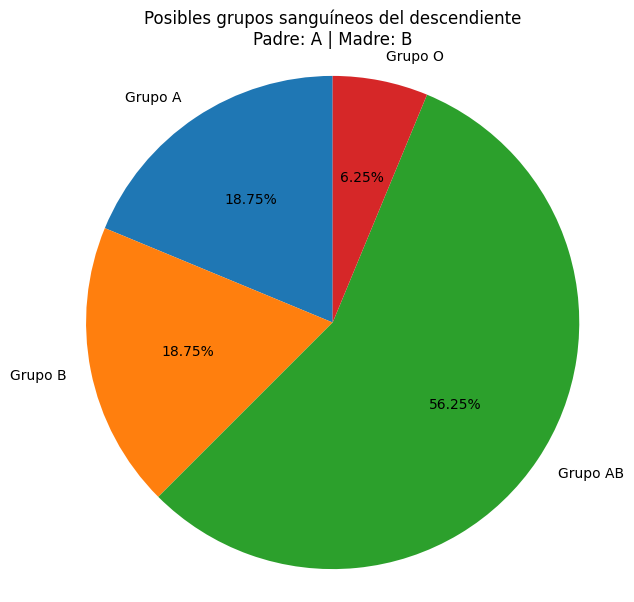


--- Análisis del registro 2 ---
Grupo sanguíneo del padre: AB
Grupo sanguíneo de la madre: O

Posibles grupos sanguíneos del descendiente:
Grupo A: 50.00%
Grupo B: 50.00%
Grupo AB: 0.00%
Grupo O: 0.00%

Suposición: los genotipos posibles de cada grupo se consideran igual de probables.


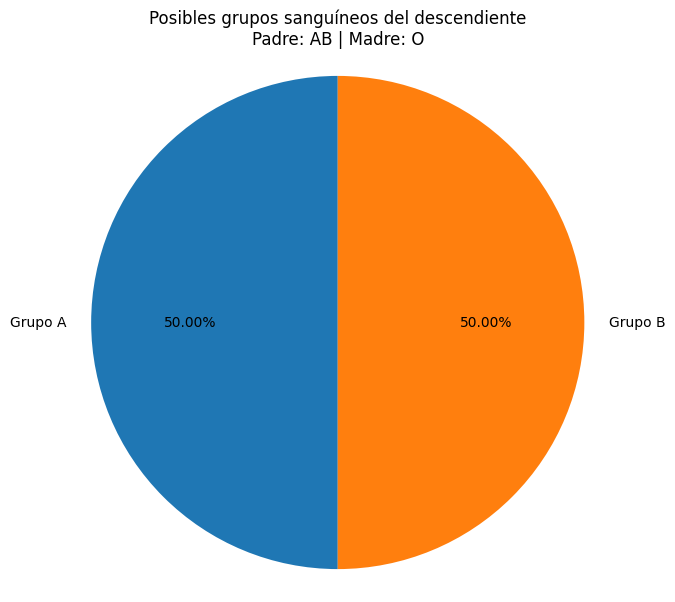


--- Análisis del registro 3 ---
Grupo sanguíneo del padre: O
Grupo sanguíneo de la madre: O

Posibles grupos sanguíneos del descendiente:
Grupo A: 0.00%
Grupo B: 0.00%
Grupo AB: 0.00%
Grupo O: 100.00%

Suposición: los genotipos posibles de cada grupo se consideran igual de probables.


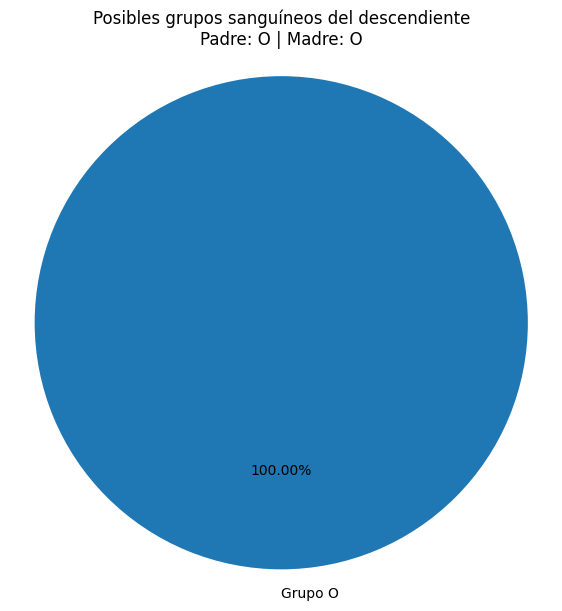


Se han guardado 3 análisis en resultados.json.


In [2]:
import json
from datetime import datetime


def analizar_archivo(archivo_entrada, archivo_salida):
    # Leo los registros del archivo JSON.
    with open(archivo_entrada, "r", encoding="utf-8") as archivo:
        registros = json.load(archivo)

    if not isinstance(registros, list):
        raise ValueError("El archivo debe contener una lista de registros.")

    resultados_guardados = []

    for numero, registro in enumerate(registros, start=1):
        try:
            if not isinstance(registro, dict):
                raise ValueError("Cada registro debe ser un diccionario.")

            # Al crear el objeto, los descriptores validan los grupos.
            analisis = HerenciaSanguinea(
                registro["grupo_padre"],
                registro["grupo_madre"]
            )

            print(f"\n--- Análisis del registro {numero} ---")
            analisis.mostrar_resultados()

            # Preparo los datos que guardaré en el archivo de salida.
            resultado = {
                "fecha_analisis": datetime.now().isoformat(
                    timespec="seconds"
                ),
                "grupo_padre": analisis.grupo_padre,
                "grupo_madre": analisis.grupo_madre,
                "porcentajes_descendencia": (
                    analisis.calcular_porcentajes()
                ),
                "suposicion": (
                    "Los genotipos posibles de cada grupo "
                    "se consideran igual de probables."
                )
            }

            resultados_guardados.append(resultado)

        except (KeyError, TypeError, ValueError) as error:
            # Si un registro es incorrecto, sigo con los siguientes.
            print(f"Error en el registro {numero}: {error}")

    # Guardo todos los análisis válidos en un nuevo archivo JSON.
    with open(archivo_salida, "w", encoding="utf-8") as archivo:
        json.dump(
            resultados_guardados,
            archivo,
            indent=4,
            ensure_ascii=False
        )

    print(
        f"\nSe han guardado {len(resultados_guardados)} "
        f"análisis en {archivo_salida}."
    )


try:
    analizar_archivo("padres.json", "resultados.json")

except FileNotFoundError:
    print("No se encuentra padres.json. Comprueba dónde está guardado.")

except json.JSONDecodeError:
    print("El archivo padres.json no tiene un formato JSON válido.")

except (ValueError, OSError) as error:
    print(f"Error: {error}")

FASE 3

In [3]:
import json
import shutil
from pathlib import Path
from datetime import datetime


class GestorArchivos:
    def __init__(self, carpeta_base="data"):
        # Guardo las rutas como atributos privados.
        self.__pending = Path(carpeta_base) / "pending"
        self.__done = Path(carpeta_base) / "done"
        self.__results = Path(carpeta_base) / "results"

        self.__crear_carpetas()

    def __crear_carpetas(self):
        # Si las carpetas ya existen, no se produce ningún error.
        for carpeta in (
            self.__pending,
            self.__done,
            self.__results
        ):
            carpeta.mkdir(parents=True, exist_ok=True)

    def __leer_archivo(self, ruta):
        with open(ruta, "r", encoding="utf-8") as archivo:
            registros = json.load(archivo)

        if not isinstance(registros, list):
            raise ValueError(
                "El archivo debe contener una lista de registros."
            )

        return registros

    def __analizar_registros(self, registros):
        resultados = []

        for numero, registro in enumerate(registros, start=1):
            if not isinstance(registro, dict):
                raise ValueError(
                    f"El registro {numero} debe ser un diccionario."
                )

            if (
                "grupo_padre" not in registro
                or "grupo_madre" not in registro
            ):
                raise ValueError(
                    f"Faltan los grupos de los padres "
                    f"en el registro {numero}."
                )

            # Los descriptores de la fase 1 validan los grupos.
            analisis = HerenciaSanguinea(
                registro["grupo_padre"],
                registro["grupo_madre"]
            )

            resultados.append({
                "fecha_analisis": datetime.now().isoformat(
                    timespec="seconds"
                ),
                "grupo_padre": analisis.grupo_padre,
                "grupo_madre": analisis.grupo_madre,
                "porcentajes_descendencia": (
                    analisis.calcular_porcentajes()
                ),
                "suposicion": (
                    "Los genotipos posibles de cada grupo "
                    "se consideran igual de probables."
                )
            })

        return resultados

    def __procesar_archivo(self, ruta):
        registros = self.__leer_archivo(ruta)
        resultados = self.__analizar_registros(registros)

        # Uso una marca temporal para distinguir cada procesamiento.
        marca = datetime.now().strftime("%Y%m%d_%H%M%S_%f")

        ruta_resultados = self.__results / (
            f"{ruta.stem}_{marca}_resultados.json"
        )

        ruta_copia = self.__done / (
            f"{ruta.stem}_{marca}{ruta.suffix}"
        )

        # Primero guardo los resultados.
        with open(
            ruta_resultados, "w", encoding="utf-8"
        ) as archivo:
            json.dump(
                resultados,
                archivo,
                indent=4,
                ensure_ascii=False
            )

        # Después copio el archivo original en done.
        shutil.copy2(ruta, ruta_copia)

        # Solo lo elimino de pending tras guardar y copiar.
        ruta.unlink()

        print(f"\nProcesado: {ruta.name}")

        for numero, resultado in enumerate(resultados, start=1):
            print(
                f"Registro {numero}: "
                f"{resultado['grupo_padre']} × "
                f"{resultado['grupo_madre']}"
            )

            for grupo, porcentaje in (
                resultado["porcentajes_descendencia"].items()
            ):
                print(f"  Grupo {grupo}: {porcentaje:.2f}%")

        print(f"Resultados guardados en: {ruta_resultados}")
        print(f"Original copiado en: {ruta_copia}")

    def procesar_pendientes(self):
        # Obtengo los archivos JSON que están pendientes.
        archivos = sorted(self.__pending.glob("*.json"))

        if not archivos:
            print(
                "No hay archivos JSON pendientes. "
                "Colócalos en data/pending y ejecuta de nuevo."
            )
            return

        procesados = 0

        for ruta in archivos:
            try:
                self.__procesar_archivo(ruta)
                procesados += 1

            except (
                json.JSONDecodeError,
                TypeError,
                ValueError,
                OSError
            ) as error:
                print(f"\nError en {ruta.name}: {error}")
                print(
                    "El archivo permanece en pending "
                    "para poder corregirlo."
                )

        print(
            f"\nArchivos procesados: "
            f"{procesados} de {len(archivos)}."
        )


# Creo el gestor y proceso los archivos pendientes.
gestor = GestorArchivos()
gestor.procesar_pendientes()

No hay archivos JSON pendientes. Colócalos en data/pending y ejecuta de nuevo.
